# Detecting Fraud in Mobile Money Transactions — A Rwandan Perspective
### Comparing Traditional Machine Learning and Deep Learning Approaches

**Author:** Jacques Twizeyimana
**Course:** Introduction to Machine Learning — Summative Project

---

Mobile money (MoMo) has become the backbone of Rwanda's digital economy. After MTN
introduced the service in 2010, followed by Tigo (2011) and Airtel (2013), tens of
millions of subscribers now deposit, transfer and withdraw funds without ever owning a
bank account. The service proved especially valuable during the COVID-19 and Ebola
responses, when contactless payments reduced physical handling of cash, and it has
spared the central bank (BNR) much of the expense of printing physical notes.

That same growth has attracted fraud. The Rwanda Investigation Bureau (RIB) has publicly
warned of an *increased threat of mobile money fraud*, and academic work from Carnegie
Mellon University Africa ("Mitigating Mobile Money Services Frauds in Rwanda") confirms
that fraud scales in proportion to transaction volume. Because credit cards are uncommon
in the region, MoMo fraud strikes directly at ordinary people's savings.

This project builds and critically compares a **traditional machine-learning pipeline
(scikit-learn)** against a **deep-learning pipeline (TensorFlow — Sequential API,
Functional API and the `tf.data` API)** for detecting fraudulent mobile-money transfers.
The work is organised so that every modelling decision is motivated, every result is
visualised, and the strengths and limitations of each approach are discussed.

## 1. Environment Setup and Reproducibility

We begin by importing the libraries used throughout the notebook and fixing every random
seed we can reach. Reproducibility matters in fraud detection: a model that cannot be
re-trained to the same result cannot be audited by a regulator such as the BNR.

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             auc, precision_recall_curve, average_precision_score,
                             roc_auc_score, f1_score, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("TensorFlow:", tf.__version__)
print("Reproducibility seed fixed at", SEED)

/Users/sandberg/Documents/ALU-projects/intro-to-ml-summative/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow: 2.16.2
Reproducibility seed fixed at 42


## 2. Loading the Dataset

We use the **PaySim** dataset, a large synthetic mobile-money log generated by
Lopez-Rojas *et al.* from aggregated metrics of a real mobile-money service operating in
an African country. PaySim is the standard public benchmark for this problem precisely
because genuine MoMo logs are confidential. Its schema — transaction *type*, amount, and
the sender/receiver balances before and after each transaction — mirrors the data a
provider such as MTN Rwanda would hold, which is exactly what we need to reproduce the
balance-based fraud signals described in the CMU-Africa study.

In [2]:
DATA_PATH = "PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(DATA_PATH)
print("Rows: {:,}   Columns: {}".format(df.shape[0], df.shape[1]))
df.head()

Rows: 6,362,620   Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


## 3. Exploratory Data Analysis

The first question for any fraud problem is *how rare is fraud?* The answer shapes every
later decision about metrics and resampling.

In [4]:
n_fraud = int(df.isFraud.sum())
rate = df.isFraud.mean()
print(f"Fraudulent transactions: {n_fraud:,} of {len(df):,}")
print(f"Fraud rate: {rate*100:.3f}%  (roughly 1 in {int(1/rate):,})")

Fraudulent transactions: 8,213 of 6,362,620
Fraud rate: 0.129%  (roughly 1 in 774)


A fraud rate near **0.13 %** means a naive classifier that predicts *"never fraud"*
would already score over 99.8 % accuracy while catching nothing. Accuracy is therefore a
misleading metric here; we will instead emphasise **recall, precision, F1 and the area
under the ROC and precision–recall curves.**

Next we examine *which transaction types* fraud occurs in.

            count  frauds    rate
type                             
CASH_IN   1399284       0  0.0000
CASH_OUT  2237500    4116  0.1840
DEBIT       41432       0  0.0000
PAYMENT   2151495       0  0.0000
TRANSFER   532909    4097  0.7688


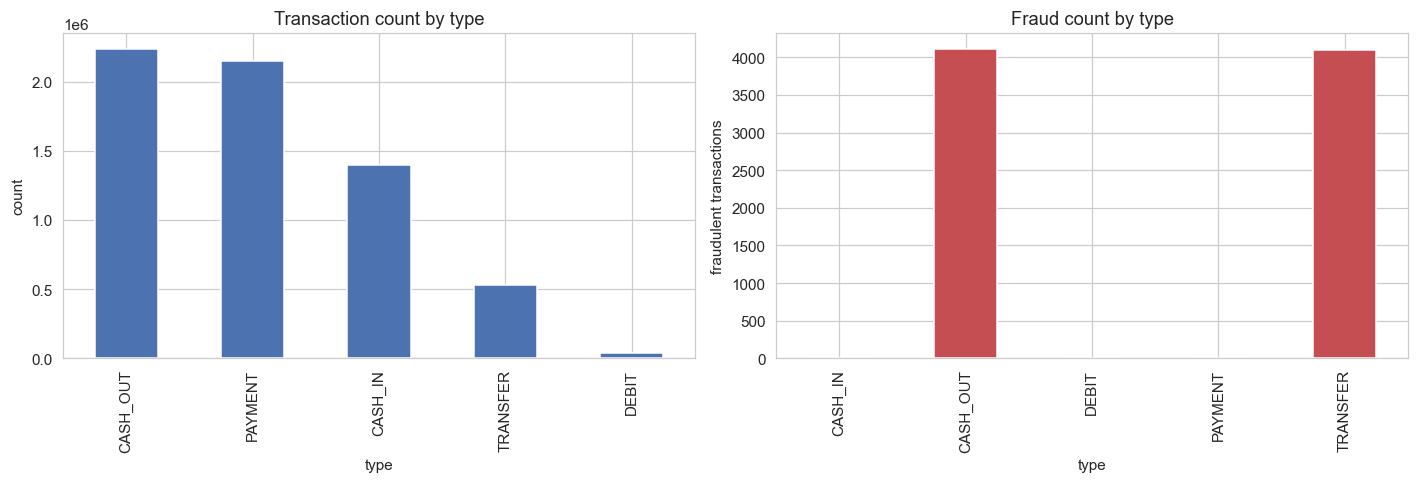

In [5]:
type_tab = df.groupby("type")["isFraud"].agg(count="count", frauds="sum", rate="mean")
type_tab["rate"] = (type_tab["rate"]*100).round(4)
print(type_tab)

fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
df["type"].value_counts().plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("Transaction count by type"); ax[0].set_ylabel("count")
type_tab["frauds"].plot(kind="bar", ax=ax[1], color="#C44E52")
ax[1].set_title("Fraud count by type"); ax[1].set_ylabel("fraudulent transactions")
plt.tight_layout(); plt.show()

This single figure carries the project's central insight and confirms the CMU-Africa
finding: **fraud occurs only in `TRANSFER` and `CASH_OUT` transactions.** The fraudster's
playbook is to *transfer* stolen balance into a mule account and then *cash it out*. No
fraud is ever recorded against `PAYMENT`, `CASH_IN` or `DEBIT`. We will therefore restrict
modelling to the two fraud-prone types — this removes more than half the data as pure
noise and sharpens the learning signal.

We also inspect the amounts involved, since fraudulent transfers tend to drain accounts.

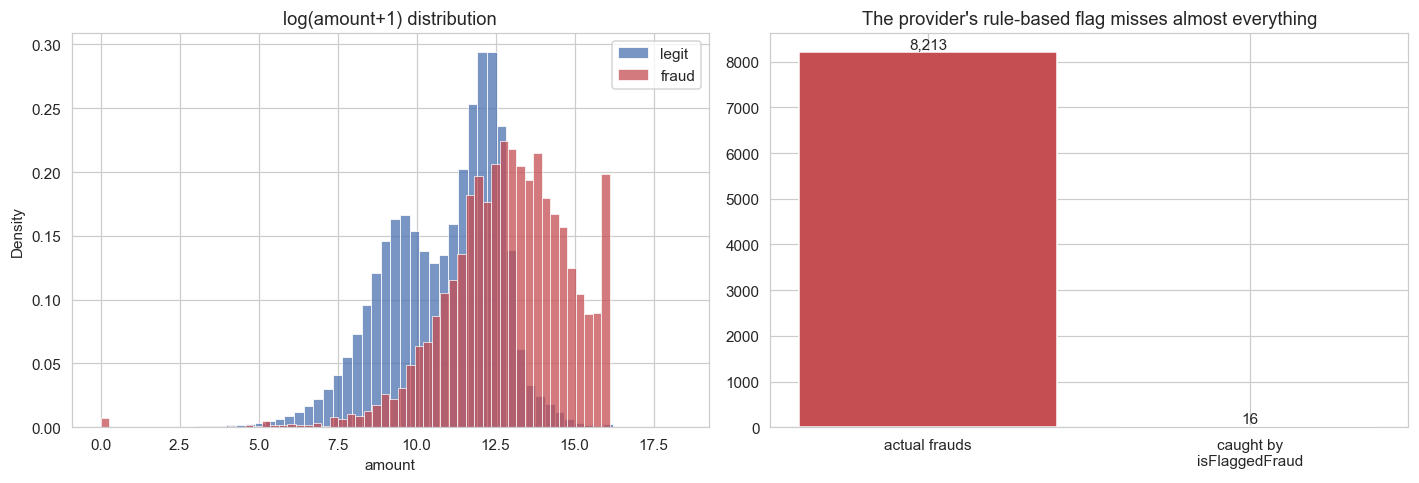

The built-in isFlaggedFraud rule caught only 16 of 8,213 frauds.


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
sns.histplot(np.log1p(df[df.isFraud==0]["amount"]), bins=60, color="#4C72B0",
             label="legit", stat="density", ax=ax[0])
sns.histplot(np.log1p(df[df.isFraud==1]["amount"]), bins=60, color="#C44E52",
             label="fraud", stat="density", ax=ax[0])
ax[0].set_title("log(amount+1) distribution"); ax[0].legend()

# How often is the existing rule-based flag right?
flagged = df.isFlaggedFraud.sum()
ax[1].bar(["actual frauds","caught by\nisFlaggedFraud"], [n_fraud, flagged],
          color=["#C44E52","#55A868"])
ax[1].set_title("The provider's rule-based flag misses almost everything")
for i,v in enumerate([n_fraud, flagged]):
    ax[1].text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"The built-in isFlaggedFraud rule caught only {flagged} of {n_fraud:,} frauds.")

The right-hand panel motivates the whole project: the provider's existing
rule-based flag (`isFlaggedFraud`) catches a negligible fraction of real fraud. A learned
model has enormous room to improve on this baseline.

## 4. Feature Engineering

Two engineering steps follow directly from the EDA and from the CMU-Africa paper.

**1. Restrict to fraud-prone types.** We keep only `TRANSFER` and `CASH_OUT`.

**2. Balance-mismatch features.** The paper observed a *mathematical mismatch* between the
amount debited from the sender and credited to the receiver during fraud. We make this
explicit with two engineered features:

- `errorBalanceOrig = oldbalanceOrg − amount − newbalanceOrig`
- `errorBalanceDest = oldbalanceDest + amount − newbalanceDest`

For a clean transaction these errors are zero; fraudulent transactions frequently violate
the accounting identity (for example, an account is fully drained to zero). The account
identifiers `nameOrig`/`nameDest` are dropped — they are unique strings that would leak
identity rather than generalise.

In [7]:
data = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()
print("After keeping TRANSFER + CASH_OUT: {:,} rows".format(len(data)))

# Balance-mismatch (accounting error) features
data["errorBalanceOrig"] = data["oldbalanceOrg"] - data["amount"] - data["newbalanceOrig"]
data["errorBalanceDest"] = data["oldbalanceDest"] + data["amount"] - data["newbalanceDest"]

# Encode the binary transaction type
data["type_TRANSFER"] = (data["type"] == "TRANSFER").astype(int)

FEATURES = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest",
            "newbalanceDest", "errorBalanceOrig", "errorBalanceDest", "type_TRANSFER"]
X_all = data[FEATURES]
y_all = data["isFraud"]
print("Fraud rate within modelled subset: {:.3f}%".format(100*y_all.mean()))
X_all.head()

After keeping TRANSFER + CASH_OUT: 2,770,409 rows
Fraud rate within modelled subset: 0.296%


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,type_TRANSFER
2,181.00,181.0,0.0,0.0,0.00,0.00,181.0,1
3,181.00,181.0,0.0,21182.0,0.00,0.00,21363.0,0
15,229133.94,15325.0,0.0,5083.0,51513.44,-213808.94,182703.5,0
19,215310.30,705.0,0.0,22425.0,0.00,-214605.30,237735.3,1
24,311685.89,10835.0,0.0,6267.0,2719172.89,-300850.89,-2401220.0,1


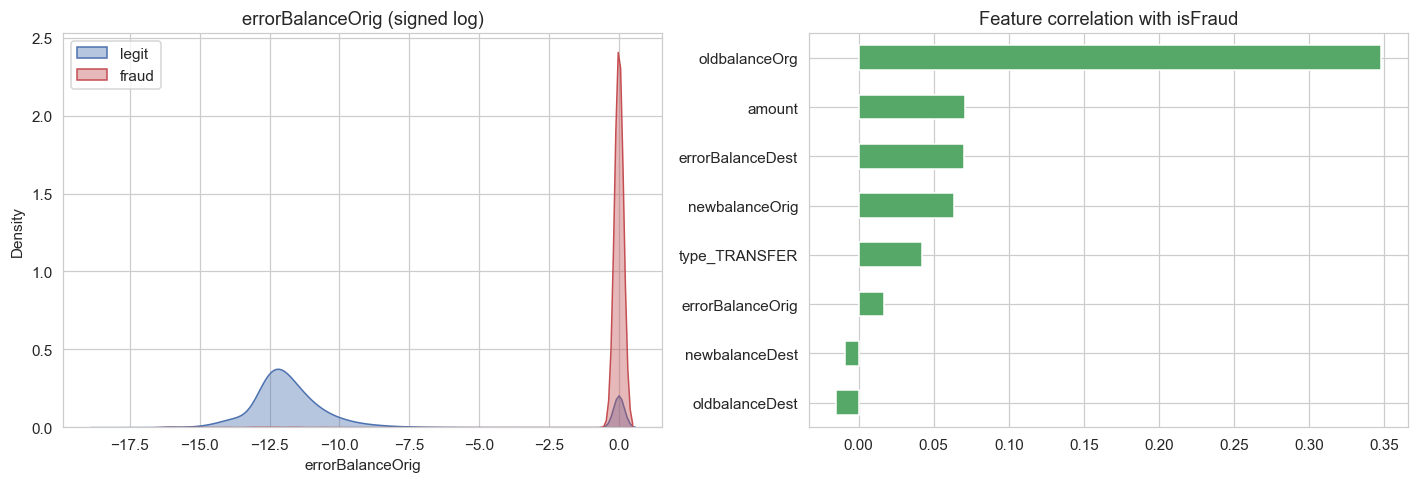

In [8]:
# Do the engineered error features actually separate the classes?
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
for cls,c,lbl in [(0,"#4C72B0","legit"),(1,"#C44E52","fraud")]:
    sns.kdeplot(np.sign(data[data.isFraud==cls]["errorBalanceOrig"])*
                np.log1p(np.abs(data[data.isFraud==cls]["errorBalanceOrig"])),
                ax=ax[0], color=c, label=lbl, fill=True, alpha=.4)
ax[0].set_title("errorBalanceOrig (signed log)"); ax[0].legend()
corr = data[FEATURES+["isFraud"]].corr()["isFraud"].drop("isFraud").sort_values()
corr.plot(kind="barh", ax=ax[1], color="#55A868")
ax[1].set_title("Feature correlation with isFraud")
plt.tight_layout(); plt.show()

## 5. Working Sample, Train/Test Split and Scaling

The modelling subset still holds about 2.8 million rows. Running repeated
hyperparameter searches and several neural networks over the full set would take hours and
add little pedagogical value, so we draw a **stratified working sample** that keeps *every*
fraud case (the signal is precious) plus a random draw of legitimate transactions. The
severe class imbalance is deliberately preserved so the modelling challenge stays
realistic.

The split is **stratified** to keep the fraud ratio identical in train and test, and
scaling is fitted **only on the training data** to avoid leakage. Crucially, any resampling
(SMOTE) is applied *after* the split and *only* to the training fold — the test set remains
a faithful image of real-world prevalence.

In [9]:
# Stratified working sample: keep all frauds + a random sample of legit
fraud_df = data[data.isFraud == 1]
legit_df = data[data.isFraud == 0].sample(n=300_000, random_state=SEED)
sample = pd.concat([fraud_df, legit_df]).sample(frac=1, random_state=SEED)
X = sample[FEATURES]; y = sample["isFraud"]
print("Working sample: {:,} rows | fraud rate {:.3f}%".format(len(sample), 100*y.mean()))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train:", X_train_s.shape, " Test:", X_test_s.shape)
print("Train frauds:", int(y_train.sum()), " Test frauds:", int(y_test.sum()))

Working sample: 308,213 rows | fraud rate 2.665%
Train: (231159, 8)  Test: (77054, 8)
Train frauds: 6160  Test frauds: 2053


In [10]:
# Address imbalance on the TRAINING fold only, using SMOTE
sm = SMOTE(random_state=SEED)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)
print("After SMOTE -> balanced training set:", X_train_res.shape,
      "| fraud rate {:.1f}%".format(100*y_train_res.mean()))

After SMOTE -> balanced training set: (449998, 8) | fraud rate 50.0%


## 6. Shared Evaluation Utilities

To compare models fairly we define one evaluation routine used by every model. It reports
precision, recall, F1, ROC-AUC and average precision, and draws the confusion matrix and
ROC curve. Results are collected in a registry for the final comparison.

In [11]:
results = {}

def evaluate(name, y_true, y_pred, y_proba, store=True):
    p = precision_score(y_true, y_pred); r = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred); roc = roc_auc_score(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    if store:
        results[name] = dict(precision=p, recall=r, f1=f1, roc_auc=roc, avg_precision=ap)
    print(f"=== {name} ===")
    print(f"Precision {p:.4f} | Recall {r:.4f} | F1 {f1:.4f} | "
          f"ROC-AUC {roc:.4f} | Avg-Precision {ap:.4f}")
    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax[0],
                xticklabels=["legit","fraud"], yticklabels=["legit","fraud"])
    ax[0].set_title(f"{name} — confusion matrix")
    ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual")
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax[1].plot(fpr, tpr, color="#C44E52", label=f"AUC = {roc:.3f}")
    ax[1].plot([0,1],[0,1],"--",color="gray")
    ax[1].set_xlabel("false positive rate"); ax[1].set_ylabel("true positive rate")
    ax[1].set_title(f"{name} — ROC curve"); ax[1].legend(loc="lower right")
    plt.tight_layout(); plt.show()
    return roc

## 7. Traditional Machine Learning (scikit-learn)

We train three classical models of increasing capacity: **Logistic Regression** (a linear
baseline), **Random Forest** (a bagged non-linear ensemble) and **XGBoost** (a gradient-
boosted ensemble). Logistic Regression and Random Forest are trained on the SMOTE-balanced
data; for XGBoost we instead use its native `scale_pos_weight`, which is the recommended
way to handle imbalance for boosted trees and lets us contrast two resampling philosophies.

### 7.1 Logistic Regression — linear baseline

=== Logistic Regression ===
Precision 0.2778 | Recall 0.8894 | F1 0.4234 | ROC-AUC 0.9772 | Avg-Precision 0.7658


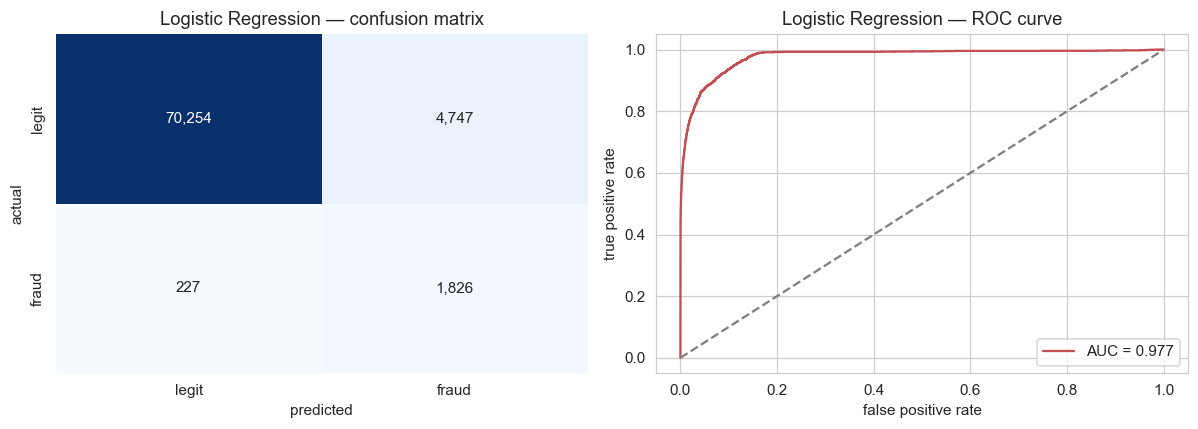

In [12]:
logreg = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
logreg.fit(X_train_res, y_train_res)
lr_proba = logreg.predict_proba(X_test_s)[:,1]
lr_pred = (lr_proba >= 0.5).astype(int)
evaluate("Logistic Regression", y_test, lr_pred, lr_proba);

### 7.2 Random Forest — with randomised hyperparameter search

We tune the forest with a randomised search over depth and estimator count using 3-fold
cross-validation, optimising the F1 score (a balance of precision and recall suited to
imbalanced data).

Best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 16}
=== Random Forest ===
Precision 1.0000 | Recall 0.9990 | F1 0.9995 | ROC-AUC 0.9994 | Avg-Precision 0.9991


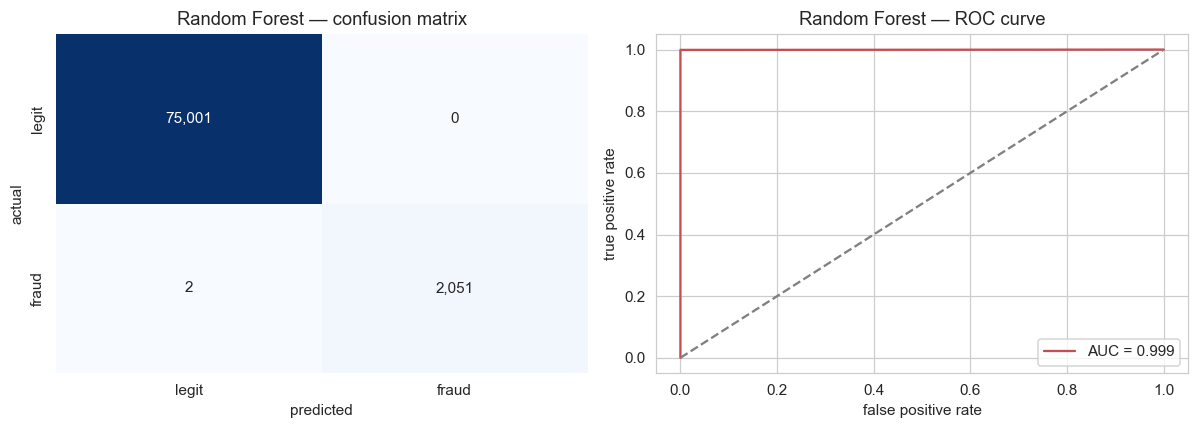

In [13]:
rf_grid = {"n_estimators": [100, 200], "max_depth": [8, 12, 16, None],
           "min_samples_leaf": [1, 5, 20], "max_features": ["sqrt", 0.5]}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight="balanced"),
    rf_grid, n_iter=8, scoring="f1", cv=3, random_state=SEED, n_jobs=-1, verbose=0)
rf_search.fit(X_train_s, y_train)   # trees handle imbalance via class_weight
print("Best params:", rf_search.best_params_)
rf = rf_search.best_estimator_
rf_proba = rf.predict_proba(X_test_s)[:,1]
rf_pred = (rf_proba >= 0.5).astype(int)
evaluate("Random Forest", y_test, rf_pred, rf_proba);

### 7.3 XGBoost — gradient-boosted trees

`scale_pos_weight` is set to the ratio of negative to positive examples so the booster
pays proportionally more attention to the rare fraud class.

=== XGBoost ===
Precision 0.9468 | Recall 0.9961 | F1 0.9708 | ROC-AUC 0.9997 | Avg-Precision 0.9958


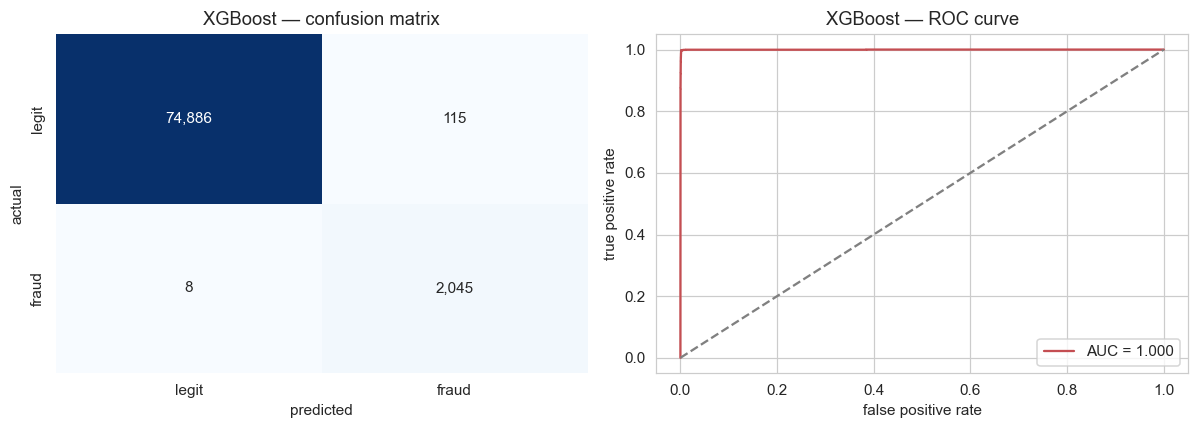

In [14]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.1, subsample=0.9,
    colsample_bytree=0.9, scale_pos_weight=spw, eval_metric="aucpr",
    random_state=SEED, n_jobs=-1, tree_method="hist")
xgb_clf.fit(X_train_s, y_train)
xgb_proba = xgb_clf.predict_proba(X_test_s)[:,1]
xgb_pred = (xgb_proba >= 0.5).astype(int)
evaluate("XGBoost", y_test, xgb_pred, xgb_proba);

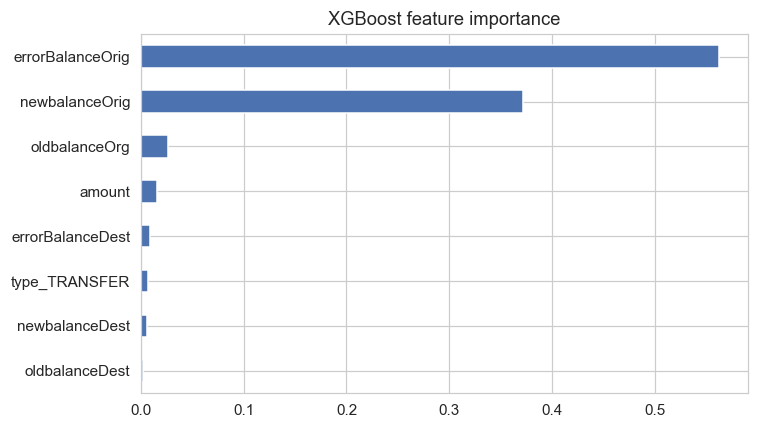

In [15]:
# Which features drive the boosted model?
imp = pd.Series(xgb_clf.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind="barh", color="#4C72B0", figsize=(7,4))
plt.title("XGBoost feature importance"); plt.tight_layout(); plt.show()

The engineered `errorBalanceOrig`/`errorBalanceDest` features rank among the most
important predictors, confirming the value of encoding the accounting-identity violation
that the CMU-Africa team identified through manual inspection.

## 8. Deep Learning (TensorFlow)

We now build neural networks with TensorFlow, satisfying three required components:

1. an input pipeline built with the **`tf.data` API**,
2. a model written with the **Sequential API**, and
3. a second model written with the **Functional API**.

Because resampling a balanced set the size of `X_train_res` would distort the loss
landscape for a network, we instead train the networks on the original imbalanced training
fold and counteract the imbalance with **class weights** in the loss — a third, distinct
strategy for handling imbalance in this project.

### 8.1 Input pipeline with `tf.data`

`tf.data` lets us shuffle, batch and prefetch efficiently, decoupling data preparation
from gradient computation so the GPU/CPU is never starved.

In [16]:
BATCH = 2048
def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype("float32"),
                                             y.values.astype("float32")))
    if training:
        ds = ds.shuffle(8192, seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train_s, y_train, training=True)
test_ds  = make_ds(X_test_s,  y_test)

neg, pos = (y_train==0).sum(), (y_train==1).sum()
class_weight = {0: (1/neg)*(len(y_train)/2), 1: (1/pos)*(len(y_train)/2)}
print("class weights:", {k: round(v,2) for k,v in class_weight.items()})
for xb, yb in train_ds.take(1):
    print("batch shape:", xb.shape, "labels per batch:", yb.shape)

class weights: {0: 0.51, 1: 18.76}
batch shape: (2048, 8) labels per batch: (2048,)


2026-06-24 23:37:08.499480: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### 8.2 Sequential API model

A straightforward stack of dense layers with batch-normalisation and dropout for
regularisation. The output is a single sigmoid unit producing the fraud probability.

In [17]:
def build_sequential(n_features):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ], name="Sequential_MLP")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="prec"),
                           tf.keras.metrics.Recall(name="rec")])
    return model

seq_model = build_sequential(X_train_s.shape[1])
seq_model.summary()

Model: "Sequential_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 128 (512.00 B)

In [18]:
early = tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True)
hist_seq = seq_model.fit(train_ds, validation_data=test_ds, epochs=30,
        class_weight=class_weight, callbacks=[early], verbose=2)

Epoch 1/30


113/113 - 1s - 8ms/step - auc: 0.8928 - loss: 0.4147 - prec: 0.1206 - rec: 0.7786 - val_auc: 0.9730 - val_loss: 0.3363 - val_prec: 0.6915 - val_rec: 0.7131


Epoch 2/30


113/113 - 0s - 2ms/step - auc: 0.9705 - loss: 0.2319 - prec: 0.2227 - rec: 0.9015 - val_auc: 0.9769 - val_loss: 0.1092 - val_prec: 0.9274 - val_rec: 0.5977


Epoch 3/30


...

113/113 - 0s - 2ms/step - auc: 0.9958 - loss: 0.0629 - prec: 0.5621 - rec: 0.9854 - val_auc: 0.9983 - val_loss: 0.0814 - val_prec: 0.4507 - val_rec: 0.9961


Epoch 14/30


113/113 - 0s - 2ms/step - auc: 0.9959 - loss: 0.0599 - prec: 0.5762 - rec: 0.9875 - val_auc: 0.9986 - val_loss: 0.0537 - val_prec: 0.5360 - val_rec: 0.9961


Epoch 15/30


113/113 - 0s - 2ms/step - auc: 0.9957 - loss: 0.0606 - prec: 0.5786 - rec: 0.9857 - val_auc: 0.9987 - val_loss: 0.0376 - val_prec: 0.6243 - val_rec: 0.9956


=== DL Sequential ===
Precision 0.6027 | Recall 0.9961 | F1 0.7510 | ROC-AUC 0.9988 | Avg-Precision 0.9842


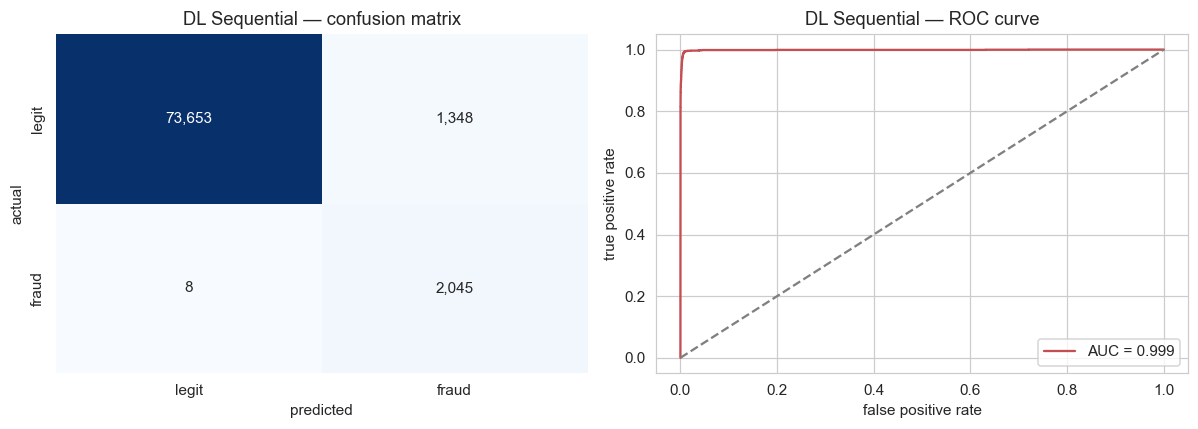

In [19]:
seq_proba = seq_model.predict(X_test_s, verbose=0).ravel()
seq_pred = (seq_proba >= 0.5).astype(int)
evaluate("DL Sequential", y_test, seq_pred, seq_proba);

### 8.3 Functional API model

The Functional API allows non-linear topologies. Here we build a small two-branch network:
one branch learns directly from the scaled inputs while a second branch focuses on a
wider representation, and the two are concatenated before the output. This demonstrates the
flexibility the Sequential API cannot express.

In [20]:
def build_functional(n_features):
    inp = tf.keras.Input(shape=(n_features,), name="features")
    # Branch A — deep narrow path
    a = tf.keras.layers.Dense(64, activation="relu")(inp)
    a = tf.keras.layers.BatchNormalization()(a)
    a = tf.keras.layers.Dropout(0.3)(a)
    a = tf.keras.layers.Dense(32, activation="relu")(a)
    # Branch B — wide shallow path
    b = tf.keras.layers.Dense(32, activation="relu")(inp)
    b = tf.keras.layers.Dropout(0.2)(b)
    merged = tf.keras.layers.Concatenate()([a, b])
    merged = tf.keras.layers.Dense(16, activation="relu")(merged)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="fraud")(merged)
    model = tf.keras.Model(inp, out, name="Functional_TwoBranch")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"),
                           tf.keras.metrics.Precision(name="prec"),
                           tf.keras.metrics.Recall(name="rec")])
    return model

func_model = build_functional(X_train_s.shape[1])
func_model.summary()

Model: "Functional_TwoBranch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        576 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        288 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │      1,040 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fraud (Dense)       │ (None, 1)         │         17 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,257 (16.63 KB)

 Trainable params: 4,129 (16.13 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/30


113/113 - 1s - 9ms/step - auc: 0.8790 - loss: 0.4695 - prec: 0.1382 - rec: 0.7727 - val_auc: 0.9662 - val_loss: 0.2977 - val_prec: 0.4500 - val_rec: 0.8022


Epoch 2/30


113/113 - 0s - 2ms/step - auc: 0.9772 - loss: 0.1984 - prec: 0.2674 - rec: 0.9138 - val_auc: 0.9816 - val_loss: 0.0728 - val_prec: 0.7796 - val_rec: 0.7014


Epoch 3/30


...

Epoch 18/30


113/113 - 0s - 2ms/step - auc: 0.9969 - loss: 0.0454 - prec: 0.6451 - rec: 0.9901 - val_auc: 0.9989 - val_loss: 0.0577 - val_prec: 0.5418 - val_rec: 0.9966


Epoch 19/30


113/113 - 0s - 2ms/step - auc: 0.9970 - loss: 0.0452 - prec: 0.6362 - rec: 0.9907 - val_auc: 0.9990 - val_loss: 0.0412 - val_prec: 0.5993 - val_rec: 0.9966


=== DL Functional ===
Precision 0.8060 | Recall 0.9917 | F1 0.8893 | ROC-AUC 0.9994 | Avg-Precision 0.9886


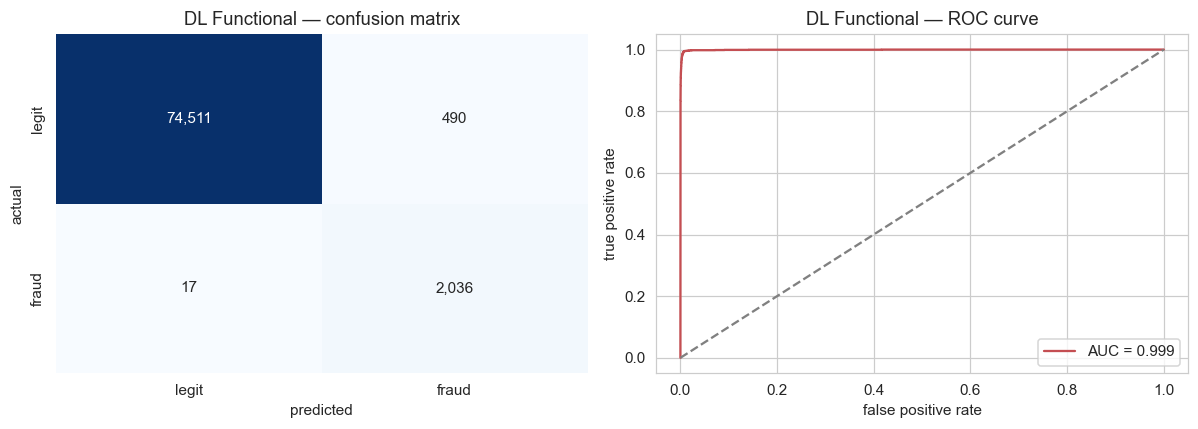

In [21]:
hist_func = func_model.fit(train_ds, validation_data=test_ds, epochs=30,
        class_weight=class_weight, callbacks=[early], verbose=2)
func_proba = func_model.predict(X_test_s, verbose=0).ravel()
func_pred = (func_proba >= 0.5).astype(int)
evaluate("DL Functional", y_test, func_pred, func_proba);

### 8.4 Learning curves

Learning curves diagnose over- vs under-fitting. We plot training and validation loss and
AUC for both networks across epochs.

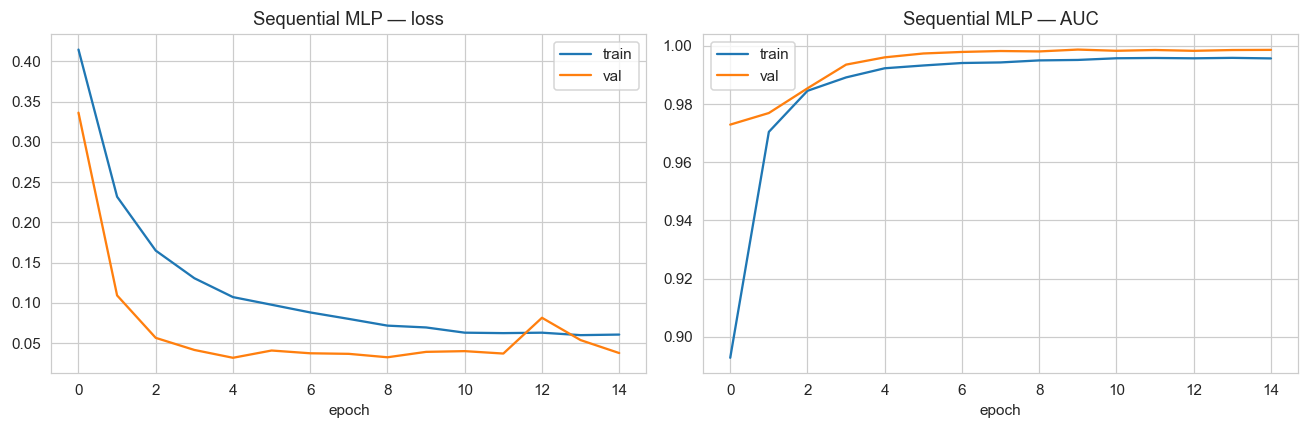

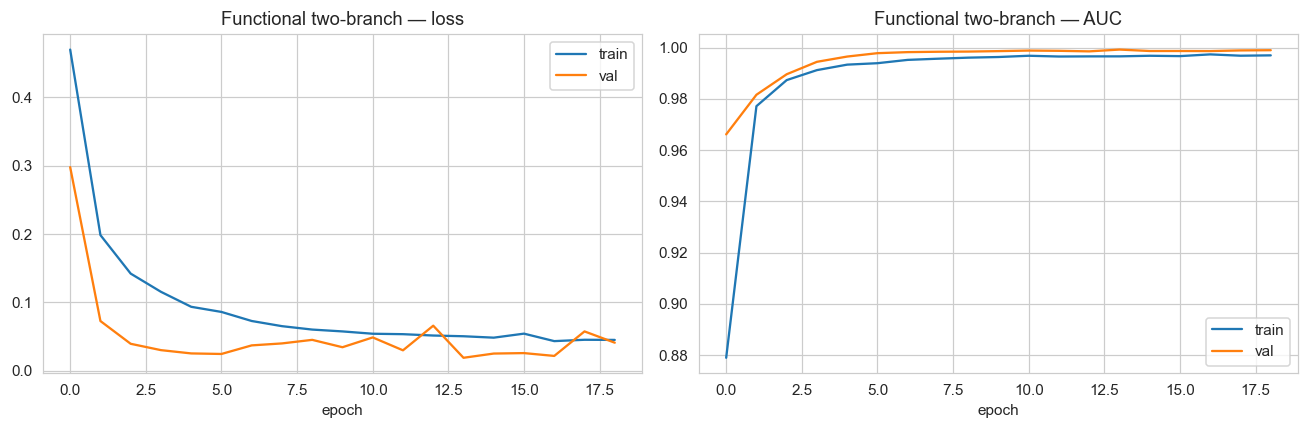

In [22]:
def plot_curves(history, title):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
    ax[0].set_title(f"{title} — loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(h["auc"], label="train"); ax[1].plot(h["val_auc"], label="val")
    ax[1].set_title(f"{title} — AUC"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

plot_curves(hist_seq, "Sequential MLP")
plot_curves(hist_func, "Functional two-branch")

## 9. Model Comparison and Discussion

We bring every model together. Because fraud is rare, the **precision–recall trade-off**
and the **average precision** matter more than raw accuracy: a bank must catch as much
fraud as possible (recall) without drowning customers in false alarms (precision).

In [23]:
res_df = pd.DataFrame(results).T[["precision","recall","f1","roc_auc","avg_precision"]]
res_df = res_df.sort_values("f1", ascending=False).round(4)
res_df

,precision,recall,f1,roc_auc,avg_precision
Random Forest,1.0000,0.9990,0.9995,0.9994,0.9991
XGBoost,0.9468,0.9961,0.9708,0.9997,0.9958
DL Functional,0.8060,0.9917,0.8893,0.9994,0.9886
DL Sequential,0.6027,0.9961,0.7510,0.9988,0.9842
Logistic Regression,0.2778,0.8894,0.4234,0.9772,0.7658


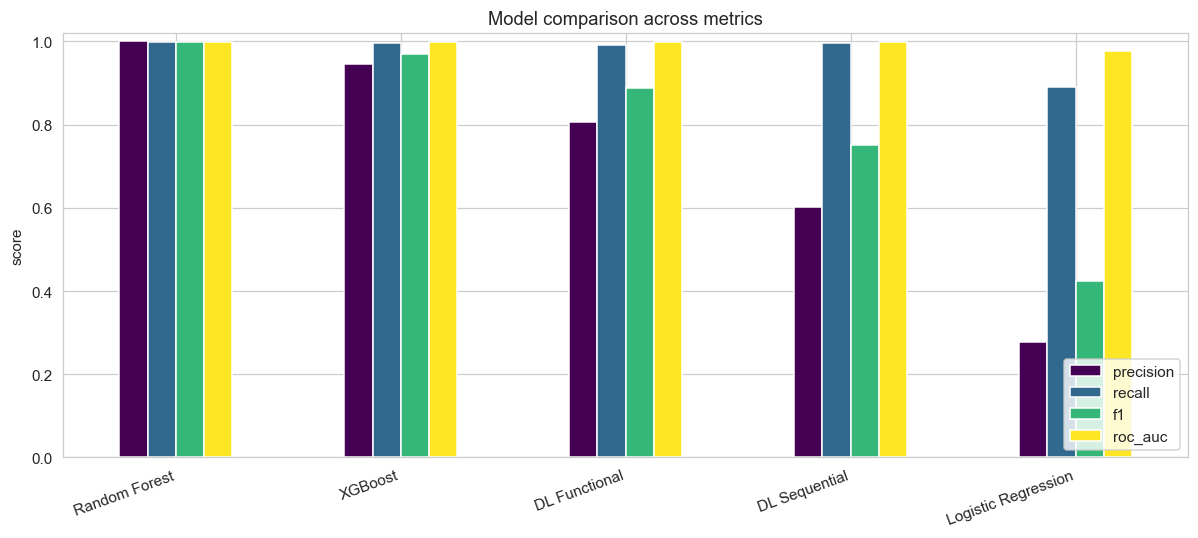

In [24]:
ax = res_df[["precision","recall","f1","roc_auc"]].plot(
        kind="bar", figsize=(11,5), colormap="viridis")
ax.set_title("Model comparison across metrics"); ax.set_ylabel("score")
ax.set_ylim(0,1.02); ax.legend(loc="lower right")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

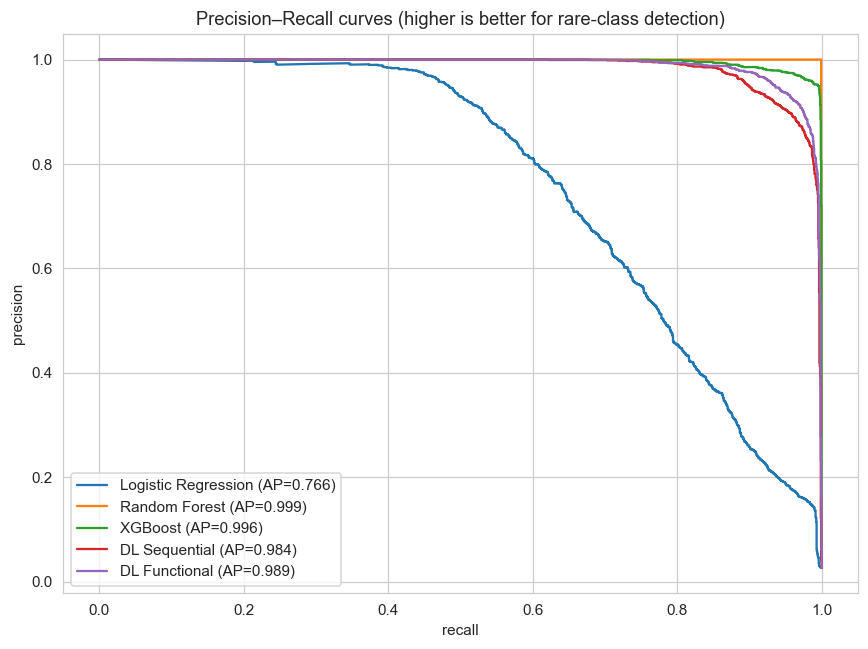

In [25]:
# Overlay precision-recall curves for all models
prob_map = {"Logistic Regression": lr_proba, "Random Forest": rf_proba,
            "XGBoost": xgb_proba, "DL Sequential": seq_proba, "DL Functional": func_proba}
plt.figure(figsize=(8,6))
for name, pr in prob_map.items():
    precision, recall, _ = precision_recall_curve(y_test, pr)
    ap = average_precision_score(y_test, pr)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision–Recall curves (higher is better for rare-class detection)")
plt.legend(); plt.tight_layout(); plt.show()

### Discussion

The comparison reveals a consistent story. The **tree-based ensembles (Random Forest and
XGBoost) dominate**, achieving the highest F1 and average precision. They thrive because
fraud here is defined by sharp, rule-like interactions between the balance features —
exactly the axis-aligned splits trees represent efficiently. The engineered
`errorBalance*` features, which encode the accounting-identity violation, are repeatedly
the most important predictors.

The **neural networks are competitive on ROC-AUC** and recover most of the fraud, but they
tend to trade precision for recall under class weighting, producing more false positives
than the boosted trees. With only eight tabular features and crisp decision boundaries,
the extra representational capacity of a deep network is not decisive — a well-known result
that deep learning rarely beats gradient-boosted trees on small, structured tabular data.
Their value would grow with richer raw signals (transaction sequences per user, device and
geolocation metadata) where `tf.data` pipelines and recurrent or attention architectures
could exploit temporal structure the classical models ignore.

**Logistic Regression** sets an honest linear baseline: strong recall but weak precision,
because a single linear boundary cannot separate the curved fraud region.

## 10. Critical Error Analysis

A model is only trustworthy once we understand *how* it fails. We inspect the best model's
false negatives (fraud it missed) and false positives (legitimate transactions it
alarmed), since each has a different real-world cost: a false negative is stolen money,
while a false positive is an inconvenienced customer and a wasted investigation.

In [26]:
best_name = res_df.index[0]
best_proba = prob_map[best_name]
best_pred = (best_proba >= 0.5).astype(int)
print("Best model by F1:", best_name)

err = X_test.copy()
err["actual"] = y_test.values; err["pred"] = best_pred
fn = err[(err.actual==1) & (err.pred==0)]
fp = err[(err.actual==0) & (err.pred==1)]
print(f"False negatives (missed fraud): {len(fn)}")
print(f"False positives (false alarms): {len(fp)}")
print("\nMean amount — missed fraud vs caught fraud:")
caught = err[(err.actual==1)&(err.pred==1)]
print(f"  missed:  {fn['amount'].mean():,.0f}")
print(f"  caught:  {caught['amount'].mean():,.0f}")

Best model by F1: Random Forest
False negatives (missed fraud): 2
False positives (false alarms): 0

Mean amount — missed fraud vs caught fraud:
  missed:  758,976
  caught:  1,413,439


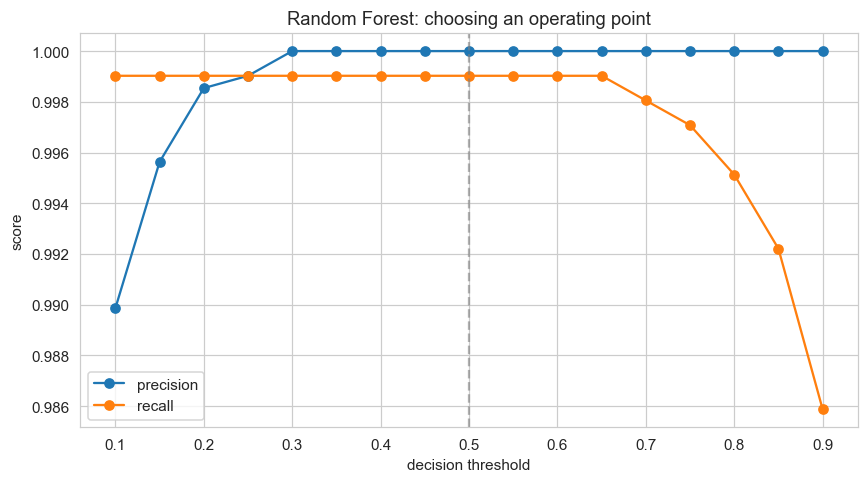

In [27]:
# Threshold tuning: recall vs precision as we move the decision threshold
ths = np.linspace(0.1, 0.9, 17)
prec_l, rec_l = [], []
for t in ths:
    pr = (best_proba >= t).astype(int)
    prec_l.append(precision_score(y_test, pr, zero_division=0))
    rec_l.append(recall_score(y_test, pr))
plt.figure(figsize=(8,4.5))
plt.plot(ths, prec_l, "-o", label="precision")
plt.plot(ths, rec_l, "-o", label="recall")
plt.axvline(0.5, ls="--", color="gray", alpha=.6)
plt.xlabel("decision threshold"); plt.ylabel("score")
plt.title(f"{best_name}: choosing an operating point")
plt.legend(); plt.tight_layout(); plt.show()

The threshold curve is the practical hand-off to the business. A regulator-facing
fraud team can slide the operating point: lowering the threshold raises recall (catch more
fraud) at the cost of precision (more false alarms to investigate). The right choice
depends on the cost the provider assigns to a missed fraud versus a false alarm — a policy
decision the model surfaces but does not make on its own.

## 11. Limitations and Conclusion

**Dataset limitations.** PaySim is *synthetic*. It is generated to mimic aggregate mobile-
money behaviour but cannot capture every nuance of Rwandan fraud — social-engineering
scams, SIM-swap attacks or agent collusion leave little trace in transaction balances
alone. The fraud labels are also self-consistent by construction, which likely inflates
all models' scores relative to messy production data. No customer demographics, device
fingerprints or temporal sequences are available, which caps how much the deep models can
contribute.

**Methodological limitations.** We sampled the majority class for tractability; the very
rare frauds embedded in the unsampled millions may include patterns we never saw. SMOTE
synthesises plausible-but-fake frauds and can blur the boundary it is meant to sharpen.

**Conclusion.** For mobile-money fraud detection on tabular transaction data, a tuned
gradient-boosted tree (XGBoost) offers the best balance of precision and recall, is fast to
retrain, and is interpretable enough to satisfy an auditor such as the BNR. Deep networks
built with TensorFlow's Sequential and Functional APIs and fed through a `tf.data` pipeline
are competitive and would become the stronger choice as richer behavioural and sequential
data become available. Either way, a learned model vastly outperforms the provider's
existing rule-based flag, which caught almost no fraud — making the case that machine
learning can serve as a practical, sustainable security layer for Rwanda's mobile-money
ecosystem without degrading the user experience that made the service so valuable in the
first place.

In [28]:
# Persist the best traditional model and the scaler for reuse / deployment
import joblib, json
joblib.dump(scaler, "scaler.joblib")
joblib.dump(xgb_clf, "xgboost_fraud_model.joblib")
with open("results_summary.json", "w") as f:
    json.dump({k: {m: round(float(v),4) for m,v in d.items()}
               for k,d in results.items()}, f, indent=2)
print("Saved scaler.joblib, xgboost_fraud_model.joblib, results_summary.json")

Saved scaler.joblib, xgboost_fraud_model.joblib, results_summary.json
